El servicio de venta de autos usados Rusty Bargain está desarrollando una aplicación para atraer nuevos clientes. Gracias a esa app, puedes averiguar rápidamente el valor de mercado de tu coche. Tienes acceso al historial: especificaciones técnicas, versiones de equipamiento y precios. Tienes que crear un modelo que determine el valor de mercado.
A Rusty Bargain le interesa:
- la calidad de la predicción;
- la velocidad de la predicción;
- el tiempo requerido para el entrenamiento

## Preparación de datos

### Importación de librerías

In [1]:
import pandas as pd
import re
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import time
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
import lightgbm as lgb
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

### Funciones
En esta celda colocaré todas las funciones que usaré a lo largo del proyecto

In [2]:
def datos_nan(datos, columna):
    print(datos[datos[columna].isna()])

def correlacion_nan(datos, columna_1, columna_2):
    unicos = datos[datos[columna_1].isna()][columna_2].unique() 
    print(unicos)   
    for i in unicos:
        print(f"{i}: {datos[datos[columna_2] == i][columna_1].unique()}")

def evaluar_modelo(model, X_train, y_train, X_test, y_test, cat_features=None):
    '''Investigando como lo pide el proyecto, encontre que se puede usar %%%time al inicio de una celda para medir el tiempo de ejecución del código que contiene.  
    Al final, me decidí por utilizar la librería time ya que me es más sencillo ver el tiempo de cada iteración del modelo cuando estoy encontrando los mejores 
    hiperparámetros en cada iteración.'''
    inicio_train = time.time()
    if cat_features is not None:
        model.fit(X_train, y_train, cat_features=cat_features)
    else:
        model.fit(X_train, y_train)
    tiempo_train = time.time() - inicio_train
    inicio_pred = time.time()
    predicciones = model.predict(X_test)
    tiempo_pred = time.time() - inicio_pred
    recm = mean_squared_error(y_test, predicciones) ** 0.5
    print(f'RECM: {recm:.2f}')
    print(f'Tiempo de entrenamiento: {tiempo_train:.2f}s')
    print(f'Tiempo de predicción: {tiempo_pred:.2f}s')
    return recm, tiempo_train, tiempo_pred

### Creación de dataframe

In [3]:
df = pd.read_csv('/datasets/car_data.csv')

### Primera exploración de los datos

In [4]:
df.info()
print(df.head(10))
columnas_nan = []
for i in df.columns:
    if df[i].isna().sum() > 0:
        columnas_nan.append(i)
print(f'Las columnas con datos NaN son: {columnas_nan}')
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   DateCrawled        354369 non-null  object
 1   Price              354369 non-null  int64 
 2   VehicleType        316879 non-null  object
 3   RegistrationYear   354369 non-null  int64 
 4   Gearbox            334536 non-null  object
 5   Power              354369 non-null  int64 
 6   Model              334664 non-null  object
 7   Mileage            354369 non-null  int64 
 8   RegistrationMonth  354369 non-null  int64 
 9   FuelType           321474 non-null  object
 10  Brand              354369 non-null  object
 11  NotRepaired        283215 non-null  object
 12  DateCreated        354369 non-null  object
 13  NumberOfPictures   354369 non-null  int64 
 14  PostalCode         354369 non-null  int64 
 15  LastSeen           354369 non-null  object
dtypes: int64(7), object(

Mis hallazgos con esta primera exploración son los siguientes: 
1) Análisis de datos duplicados
2) Columna 'NumberOfPictures': todos los datos estadísticos tienen valor '0', lo que indica que todas las filas contienen '0'. Haré una comprobación adicional y si se comprueba la hipótesis entonces eliminaré la columna ya que no aporta información al análisis 
3) Cambiar todos los nombres de columna a snake_case
4) Columnas con tipo de dato incorrecto:  
| Columna | Tipo de dato inicial | Tipo de dato propuesto |
|---------|----------------------|------------------------|
| DateCrawled | object | date |
| DateCreated | object | date |
| LastSeen | object | date |  

5) Existen datos NaN en las columnas 'VehicleType', 'Gearbox', 'Model', 'FuelType', 'NotRepaired', en esas columnas revisaré si puedo encontrar alguna relación con datos de otras columnas para asignar valores, o los dejaré como NaN si fuese necesario.
6) Consideraciones especiales por columna:
| Columna | Observación |
|---------|-------------|
| Price | Existen una o más filas con valor 0, vale la pena explorar el motivo de esto |
| RegistrationYear | Los valores mínimo y máximo son sospechosos, hay que revisar más a fondo |
| Power | Existen una o más filas con valor 0, vale la pena explorar el motivo de esto |
| RegistrationMonth | Existen una o más filas con valor 0, vale la pena explorar el motivo de esto |  
7) Revisión de columnas 'date_crawled', 'registration_year', 'registration_month'  
8) Eliminar columnas sin relevacia para el modelo 
9) Análisis de 'brand' vs 'model'  

### Limpieza de datos

#### 1) Análisis de datos duplicados

In [5]:
print(f"Filas duplicadas: {df.duplicated().sum()}")

Filas duplicadas: 262


In [6]:
# Existen 262 filas completamente duplicadas, procedo a eliminarlas ya que no aportan valor al modelo
df = df.drop_duplicates()

#### 2) Columna 'NumberOfPictures': todos los datos estadísticos tienen valor '0', lo que indica que todas las filas contienen '0'. Haré una comprobación adicional y si se comprueba la hipótesis entonces eliminaré la columna ya que no aporta información al análisis

In [7]:
df = df.drop('NumberOfPictures', axis = 1)
print(df.columns)

Index(['DateCrawled', 'Price', 'VehicleType', 'RegistrationYear', 'Gearbox',
       'Power', 'Model', 'Mileage', 'RegistrationMonth', 'FuelType', 'Brand',
       'NotRepaired', 'DateCreated', 'PostalCode', 'LastSeen'],
      dtype='object')


#### 3) Cambiar todos los nombres de columna a snake_case

In [8]:
columnas_snake = []
for i in df.columns:
    columnas_snake.append(re.sub(r'([a-z])([A-Z][a-z])', r'\1_\2', i).lower())
df.columns = columnas_snake
print(df.columns)


Index(['date_crawled', 'price', 'vehicle_type', 'registration_year', 'gearbox',
       'power', 'model', 'mileage', 'registration_month', 'fuel_type', 'brand',
       'not_repaired', 'date_created', 'postal_code', 'last_seen'],
      dtype='object')


#### 4) Columnas con tipo de dato incorrecto:  
| Columna | Tipo de dato inicial | Tipo de dato propuesto |
|---------|----------------------|------------------------|
| DateCrawled | object | date |
| DateCreated | object | date |
| LastSeen | object | date |

In [9]:
df['date_crawled'] = pd.to_datetime(df['date_crawled'], format='%d/%m/%Y %H:%M')
df['date_created'] = pd.to_datetime(df['date_created'], format='%d/%m/%Y %H:%M')
df['last_seen'] = pd.to_datetime(df['last_seen'], format='%d/%m/%Y %H:%M')
print(df[['date_crawled', 'date_created', 'last_seen']].head(10))
print(df[['date_crawled', 'date_created', 'last_seen']].dtypes)

         date_crawled date_created           last_seen
0 2016-03-24 11:52:00   2016-03-24 2016-04-07 03:16:00
1 2016-03-24 10:58:00   2016-03-24 2016-04-07 01:46:00
2 2016-03-14 12:52:00   2016-03-14 2016-04-05 12:47:00
3 2016-03-17 16:54:00   2016-03-17 2016-03-17 17:40:00
4 2016-03-31 17:25:00   2016-03-31 2016-04-06 10:17:00
5 2016-04-04 17:36:00   2016-04-04 2016-04-06 19:17:00
6 2016-04-01 20:48:00   2016-04-01 2016-04-05 18:18:00
7 2016-03-21 18:54:00   2016-03-21 2016-03-25 16:47:00
8 2016-04-04 23:42:00   2016-04-04 2016-04-04 23:42:00
9 2016-03-17 10:53:00   2016-03-17 2016-03-31 17:17:00
date_crawled    datetime64[ns]
date_created    datetime64[ns]
last_seen       datetime64[ns]
dtype: object


In [10]:
# Parece que no hay hora y minuto en la columna 'date_created', investigando un poco vi que si hay datos iguales para la hora o fecha, 
# pandas no muestra esa información ya que no aporta valor, de cualquier manera revisaré los datos unicos de hora y minuto en esta columna
print(df['date_created'].dt.hour.unique())
print(df['date_created'].dt.minute.unique())

[0]
[0]


#### 5) Existen datos NaN en las columnas 'VehicleType', 'Gearbox', 'Model', 'FuelType', 'NotRepaired', en esas columnas revisaré si puedo encontrar alguna relación con datos de otras columnas para asignar valores, o hare una sustitución por 'unknown' si fuera necesario.

##### 5.1) Columna 'vehicle_type'

In [11]:
datos_nan(df, 'vehicle_type')

              date_crawled  price vehicle_type  registration_year gearbox  \
0      2016-03-24 11:52:00    480          NaN               1993  manual   
16     2016-04-01 12:46:00    300          NaN               2016     NaN   
22     2016-03-23 14:52:00   2900          NaN               2018  manual   
26     2016-03-10 19:38:00   5555          NaN               2017  manual   
31     2016-03-29 16:57:00    899          NaN               2016  manual   
...                    ...    ...          ...                ...     ...   
354346 2016-03-07 17:06:00   2600          NaN               2005    auto   
354351 2016-03-11 23:40:00   1900          NaN               2000  manual   
354361 2016-03-09 13:37:00   5250          NaN               2016    auto   
354364 2016-03-21 09:50:00      0          NaN               2005  manual   
354365 2016-03-14 17:48:00   2200          NaN               2005     NaN   

        power     model  mileage  registration_month fuel_type  \
0        

Mi hipótesis es que puedo hacer una correlación entre la columna 'vehicle_type' y la columna 'model', por lo que revisaré cuando el tipo de vehículo es NaN que valores diferentes tenemos en 'model' y con esa información, revisaré que tipo de auto tiene cada modelo (comprobar si hay correlación)

In [12]:
correlacion_nan(df, 'vehicle_type', 'model')

['golf' 'polo' 'meriva' 'c4' 'clio' 'kangoo' 'corsa' 'punto' 'other'
 'astra' '5er' 'ka' 'insignia' 'civic' '3er' '100' 'sportage' 'fabia'
 'twingo' 'almera' 'zafira' 'caddy' nan 'i_reihe' 'fiesta' 'espace' 'jazz'
 'a_klasse' 'transporter' 'seicento' 'modus' 'c1' 'fox' 'c_max' 'ibiza'
 '2_reihe' '3_reihe' 'e_klasse' '500' 'cooper' '1er' 'galaxy' 'a3'
 'qashqai' 'lanos' 'megane' 'passat' 'scenic' 'b_klasse' 'leon' 'vectra'
 'c_klasse' '6_reihe' 'touran' 'transit' 'cr_reihe' 'focus' 'carnival'
 'fusion' 'fortwo' 'cordoba' 'sprinter' 'mondeo' 'sharan' 'v70' 'c_reihe'
 'rio' 'kaefer' 'a6' 'ducato' 'calibra' 'a4' 'clk' 'ptcruiser' '4_reihe'
 's_klasse' 'arosa' 'matiz' 'beetle' 'stilo' 'v40' 'berlingo' 'signum'
 'primera' 'c2' 'tt' 'freelander' 'yaris' 'picanto' 'tigra' 'samara'
 'scirocco' '601' 'agila' 'combo' 'swift' 'auris' 'avensis' 'mx_reihe'
 'aygo' 's_max' 'logan' 'colt' 'exeo' 'q7' '80' 'lupo' 'omega' 'ypsilon'
 'getz' 's60' 'accord' 'alhambra' 'octavia' '7er' 'kadett' 'grand'
 'sup

No encontré una correlación directa entre en modelo y el tipo de vehículo, hare la misma exploración para la marca

In [13]:
correlacion_nan(df, 'vehicle_type', 'brand')

['volkswagen' 'opel' 'citroen' 'renault' 'fiat' 'hyundai' 'seat' 'bmw'
 'ford' 'honda' 'audi' 'kia' 'skoda' 'nissan' 'mitsubishi' 'mercedes_benz'
 'sonstige_autos' 'peugeot' 'volvo' 'toyota' 'chevrolet' 'trabant' 'mini'
 'daewoo' 'porsche' 'suzuki' 'mazda' 'lancia' 'smart' 'chrysler' 'jaguar'
 'land_rover' 'rover' 'lada' 'dacia' 'saab' 'alfa_romeo' 'daihatsu'
 'subaru' 'jeep']
volkswagen: [nan 'small' 'sedan' 'wagon' 'coupe' 'bus' 'other' 'convertible' 'suv']
opel: [nan 'other' 'wagon' 'coupe' 'sedan' 'bus' 'convertible' 'small' 'suv']
citroen: [nan 'bus' 'coupe' 'other' 'small' 'sedan' 'wagon' 'convertible' 'suv']
renault: ['small' nan 'bus' 'convertible' 'sedan' 'wagon' 'coupe' 'suv' 'other']
fiat: ['small' nan 'wagon' 'sedan' 'convertible' 'bus' 'coupe' 'other' 'suv']
hyundai: [nan 'small' 'wagon' 'suv' 'sedan' 'coupe' 'bus' 'other' 'convertible']
seat: ['small' nan 'wagon' 'sedan' 'bus' 'other' 'coupe' 'suv']
bmw: ['sedan' 'wagon' 'convertible' 'coupe' nan 'small' 'suv' 'other' 'bu

Ya que mis 2 hipótesis fueron rechazadas (no hay una correlación directa entre el modelo o marca respecto al tipo de vehículo) voy a calcular el porcentaje de datos NaN en la columna, con esto puedo ver el impacto que puede tener una futura imputación

In [14]:
print(f"El total de datos NaN en la columna es: {df['vehicle_type'].isna().sum()}")
print(f"El total de datos en la columna es: {len(df['vehicle_type'])}")
print(f"El porcentaje de datos NaN en la columna es de {(df['vehicle_type'].isna().sum()) / (len(df['vehicle_type'])) * 100:.2f}%")

El total de datos NaN en la columna es: 37484
El total de datos en la columna es: 354107
El porcentaje de datos NaN en la columna es de 10.59%


El porcentaje de datos NaN respecto al total de datos es de 10.58%, esta no es una cantidad menor. Ahora, revisaré los porcentajes de cada uno de los diferentes tipos de vehículo.

In [15]:
tipos = df[~df['vehicle_type'].isna()]['vehicle_type'].unique()
print(tipos)
for i in tipos:
        print(f"Tipo: {i} | Cantidad: {(df['vehicle_type'] == i).sum()} | Porcentaje: {((df['vehicle_type'] == i).sum()) / len(~df['vehicle_type'].isna()) * 100:.2f}%")

['coupe' 'suv' 'small' 'sedan' 'convertible' 'bus' 'wagon' 'other']
Tipo: coupe | Cantidad: 16147 | Porcentaje: 4.56%
Tipo: suv | Cantidad: 11991 | Porcentaje: 3.39%
Tipo: small | Cantidad: 79753 | Porcentaje: 22.52%
Tipo: sedan | Cantidad: 91399 | Porcentaje: 25.81%
Tipo: convertible | Cantidad: 20180 | Porcentaje: 5.70%
Tipo: bus | Cantidad: 28752 | Porcentaje: 8.12%
Tipo: wagon | Cantidad: 65115 | Porcentaje: 18.39%
Tipo: other | Cantidad: 3286 | Porcentaje: 0.93%


Todos estos cálculos fueron realizados enfocados en hacer una imputación proporcional, al revisar las implicaciones de esto tomé la decisión de imputar los datos como 'unknown', esto debido a que al hacer una imputación proporcional, si bien se respeta la proporción de cada una de las categorías, la realidad es que podemos estar alimentando los futuros modelos con datos incorrectos, por lo que considero mejor manejar una nueva categoría.

In [16]:
df['vehicle_type'] = df['vehicle_type'].fillna('unknown')
print(df['vehicle_type'].isna().sum())

0


##### 5.2) Columna 'gearbox'

In [17]:
print(df[df['gearbox'].isna()])

              date_crawled  price vehicle_type  registration_year gearbox  \
15     2016-03-11 21:39:00    450        small               1910     NaN   
16     2016-04-01 12:46:00    300      unknown               2016     NaN   
32     2016-03-15 20:59:00    245        sedan               1994     NaN   
37     2016-03-28 17:50:00   1500      unknown               2016     NaN   
40     2016-03-26 22:06:00      0      unknown               1990     NaN   
...                    ...    ...          ...                ...     ...   
354288 2016-03-16 13:36:00   3300        wagon               2006     NaN   
354305 2016-04-03 13:46:00   3500      unknown               1995     NaN   
354329 2016-03-30 20:55:00    350        small               1996     NaN   
354338 2016-03-31 19:52:00    180      unknown               1995     NaN   
354365 2016-03-14 17:48:00   2200      unknown               2005     NaN   

        power   model  mileage  registration_month fuel_type           bran

Buscaré correlación entre 'gearbox' y 'model'

In [18]:
correlacion_nan(df, 'gearbox', 'model')

['ka' 'polo' 'golf' 'kangoo' 'corsa' 'astra' 'insignia' nan '3er' '100'
 'other' 'a3' 'fortwo' 'e_klasse' 'espace' 'jazz' 'a_klasse' 'a6'
 'transporter' 'c1' 'fox' 'touran' 'a4' 'punto' 'zafira' 'fiesta' 'a2'
 'c_klasse' 'kalos' 'superb' 'twingo' 'caddy' 'cayenne' 'cr_reihe'
 'meriva' 'fusion' 'eos' 'mondeo' 'passat' 'v70' 'ibiza' 'clio' 'vectra'
 'm_klasse' 'tucson' 'lupo' 'touareg' 'sprinter' 'berlingo' 'sharan' '5er'
 'civic' '1er' 'focus' 'agila' '601' '500' 'micra' 'seicento' 'v40' 'colt'
 'alhambra' 'omega' 'kaefer' 'c4' 'octavia' 'pajero' 'escort' 'accord'
 'q7' 'grand' 'altea' 'megane' 'mx_reihe' 'primera' 'cuore' 'kadett'
 'getz' 'niva' 'transit' 'fabia' 'one' 's_klasse' '2_reihe' '911' 'arosa'
 'toledo' 'tt' '6_reihe' '1_reihe' '3_reihe' '156' 'scenic' 'panda'
 'galaxy' 'boxster' 'tiguan' 'roadster' 'aveo' 'jetta' 'c5' '80' 'duster'
 'forfour' 'cordoba' 'stilo' 'aygo' 'z_reihe' 'cooper' 'x_reihe'
 'g_klasse' 'bora' 'c_max' 'jimny' '147' 'ducato' 'combo' 'sl' 'ptcruiser'
 'lyb

No hay una correlación directa. Hay ciertos modelos, como el 'serie_1' no hay transmisión 'manual' y 'auto', lo que nos puede hacer pensar que solo existe ese tipo de transmisión para ese modelo en específico, sin embargo como no podemos asegurar esto, y para evitar generar ruido artificial para el modelo, voy a sustituir los valores NaN por 'unknown'

In [19]:
df['gearbox'] = df['gearbox'].fillna('unknown')
print(df['gearbox'].isna().sum())

0


##### 5.3) Columna 'model'

In [20]:
print(df[df['model'].isna()])

              date_crawled  price vehicle_type  registration_year  gearbox  \
1      2016-03-24 10:58:00  18300        coupe               2011   manual   
59     2016-03-29 15:48:00      1          suv               1994   manual   
81     2016-04-03 12:56:00    350        small               1997   manual   
115    2016-03-20 18:53:00      0        small               1999  unknown   
135    2016-03-27 20:51:00   1450        sedan               1992   manual   
...                    ...    ...          ...                ...      ...   
354245 2016-03-07 16:37:00    560        small               2001     auto   
354321 2016-03-15 13:52:00   9400        wagon               2007   manual   
354338 2016-03-31 19:52:00    180      unknown               1995  unknown   
354351 2016-03-11 23:40:00   1900      unknown               2000   manual   
354365 2016-03-14 17:48:00   2200      unknown               2005  unknown   

        power model  mileage  registration_month fuel_type     

No se visualiza ninguna correlación, como en los casos anteriores hago la sustitución por 'unknown'

In [21]:
df['model'] = df['model'].fillna('unknown')
print(df['model'].isna().sum())

0


##### 5.4) Columna 'fuel_type'

In [22]:
print(df[df['fuel_type'].isna()])

              date_crawled  price vehicle_type  registration_year  gearbox  \
9      2016-03-17 10:53:00    999        small               1998   manual   
13     2016-03-21 21:37:00   2500        wagon               2004   manual   
26     2016-03-10 19:38:00   5555      unknown               2017   manual   
36     2016-03-11 11:50:00   1600        other               1991   manual   
41     2016-03-30 20:38:00   7500        sedan               2002     auto   
...                    ...    ...          ...                ...      ...   
354339 2016-03-20 12:46:00   3850  convertible               2006   manual   
354346 2016-03-07 17:06:00   2600      unknown               2005     auto   
354351 2016-03-11 23:40:00   1900      unknown               2000   manual   
354361 2016-03-09 13:37:00   5250      unknown               2016     auto   
354365 2016-03-14 17:48:00   2200      unknown               2005  unknown   

        power     model  mileage  registration_month fuel_type 

Reviso una posible correlación con la columna 'model'

In [23]:
correlacion_nan(df, 'fuel_type', 'model')

['golf' 'passat' 'c4' 'kadett' 'e_klasse' 'other' 'signum' 'unknown'
 'astra' '5er' 'ka' 'insignia' 'transporter' 'escort' 'omega' '3er' 'a4'
 'punto' 'a_klasse' 'twingo' 'a6' 'cordoba' 'mondeo' 'impreza' 'c_klasse'
 'corsa' 'fox' 'spider' 'ibiza' '3_reihe' 'polo' '4_reihe' 'laguna' 'lupo'
 '1er' 'a3' 'fiesta' '159' 'touran' 'micra' 'kalos' 'civic' 'clio'
 'scenic' 'i_reihe' 'mx_reihe' 's_klasse' 'meriva' 'corolla' 'vectra'
 '6_reihe' 'focus' 'carnival' 'galant' 'galaxy' 'megane' '500' 'modus'
 'c_reihe' 'octavia' 'ducato' 'calibra' 'sharan' '2_reihe' 'ptcruiser'
 'espace' 'kangoo' '7er' 'beetle' 'v40' 'c_max' 'sprinter' 'clk' 'x_reihe'
 '1_reihe' 'arosa' 'berlingo' 'tt' 'zafira' 'freelander' 'yaris'
 'seicento' 'picanto' '900' 'caddy' 'tigra' 'scirocco' '601' 'swift'
 'jetta' 'matiz' 'primera' 'fortwo' 'auris' 'aygo' 'bora' '5_reihe'
 's_max' 'logan' 'cooper' 'q7' '147' 'm_reihe' 'cherokee' 'kaefer' 'combo'
 'ypsilon' 'c1' 'agila' 'pajero' 'accord' 'altea' 'colt' 'niva' 'superb'
 'cuo

No noto una correlación directa, haré la sustitución correspondiente

In [24]:
df['fuel_type'] = df['fuel_type'].fillna('unknown')
print(df['fuel_type'].isna().sum())

0


##### 5.5) Columna 'not_repaired'

In [25]:
print(df[df['not_repaired'].isna()])

              date_crawled  price vehicle_type  registration_year  gearbox  \
0      2016-03-24 11:52:00    480      unknown               1993   manual   
2      2016-03-14 12:52:00   9800          suv               2004     auto   
8      2016-04-04 23:42:00  14500          bus               2014   manual   
9      2016-03-17 10:53:00    999        small               1998   manual   
12     2016-03-15 22:49:00    999        wagon               1995   manual   
...                    ...    ...          ...                ...      ...   
354349 2016-03-16 17:06:00   5999        wagon               2005   manual   
354356 2016-04-04 11:45:00    999  convertible               2000   manual   
354357 2016-03-09 11:36:00   1690        wagon               2004   manual   
354365 2016-03-14 17:48:00   2200      unknown               2005  unknown   
354368 2016-03-20 19:41:00   3400        wagon               2002   manual   

        power    model  mileage  registration_month fuel_type  

No puedo notar alguna relación entre columnas respecto a 'not_repaired', voy a revisar los valores únicos de la columna (debería ser categórica)

In [26]:
print(df['not_repaired'].unique())

[nan 'yes' 'no']


Dado que no hay una relación directa con otras columnas, procedo a hacer la sustitución pertinente

In [27]:
df['not_repaired'] = df['not_repaired'].fillna('unknown')
print(df['not_repaired'].isna().sum())

0


#### 6) Consideraciones especiales por columna:
| Columna | Observación |
|---------|-------------|
| Price | Existen una o más filas con valor 0, vale la pena explorar el motivo de esto |
| RegistrationYear | Los valores mínimo y máximo son sospechosos, hay que revisar más a fondo |
| Power | Existen una o más filas con valor 0, vale la pena explorar el motivo de esto |
| RegistrationMonth | Existen una o más filas con valor 0, vale la pena explorar el motivo de esto |

##### 6.1) Columna 'price'
Voy a revisar los datos donde 'price' sea 0

In [28]:
print(df[df['price'] == 0])

              date_crawled  price vehicle_type  registration_year  gearbox  \
7      2016-03-21 18:54:00      0        sedan               1980   manual   
40     2016-03-26 22:06:00      0      unknown               1990  unknown   
111    2016-03-19 18:40:00      0      unknown               2017   manual   
115    2016-03-20 18:53:00      0        small               1999  unknown   
152    2016-03-11 18:55:00      0          bus               2004   manual   
...                    ...    ...          ...                ...      ...   
354205 2016-03-09 15:56:00      0      unknown               2000   manual   
354238 2016-03-20 14:55:00      0        small               2002   manual   
354248 2016-03-24 13:48:00      0        small               1999   manual   
354277 2016-03-10 22:55:00      0        small               1999   manual   
354364 2016-03-21 09:50:00      0      unknown               2005   manual   

        power    model  mileage  registration_month fuel_type  

No noto alguna relación directa con alguna columna, voy a asumir que esos datos son erroneos (no puede haber precio 0 para un auto en venta), por lo que los voy a eliminar 

In [29]:
df = df[df['price'] >0]
print(df.describe())

               price  registration_year          power        mileage  \
count  343337.000000      343337.000000  343337.000000  343337.000000   
mean     4554.970603        2004.090573     110.995759  128338.352697   
std      4515.250607          78.442725     188.243446   37521.991319   
min         1.000000        1000.000000       0.000000    5000.000000   
25%      1200.000000        1999.000000      69.000000  125000.000000   
50%      2890.000000        2003.000000     105.000000  150000.000000   
75%      6500.000000        2008.000000     143.000000  150000.000000   
max     20000.000000        9999.000000   20000.000000  150000.000000   

       registration_month    postal_code  
count       343337.000000  343337.000000  
mean             5.777432   50681.952499  
std              3.698455   25745.300391  
min              0.000000    1067.000000  
25%              3.000000   30449.000000  
50%              6.000000   49525.000000  
75%              9.000000   71229.000000 

Sigue habiendo precios sospechosamente bajos, haré una revisión un poco más extensa

In [30]:
print(df['price'].quantile([0.001, 0.005, 0.01, 0.02, 0.05]))

0.001      1.0
0.005     50.0
0.010    100.0
0.020    200.0
0.050    350.0
Name: price, dtype: float64


In [31]:
print(df['price'].quantile([0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008, 0.009, 0.010]))

0.001      1.0
0.002      1.0
0.003      1.0
0.004     15.0
0.005     50.0
0.006     60.0
0.007     90.0
0.008    100.0
0.009    100.0
0.010    100.0
Name: price, dtype: float64


Noto que los precios entre 1 y 15 se repiten de forma anómala (percentiles 0.1%-0.3% todos en 1 exacto), consistente con valores de placeholder o error de captura, mientras que a partir de 16 la distribución adquiere un comportamiento gradual y creíble. Voy a establecer un umbral de 100 como precio mínimo válido, ofreciendo margen de seguridad adicional sobre el punto de quiebre identificado (16) y alineado con un valor de referencia razonable de mercado, considerando que pueda haber autos no funcionales (chatarra) dentro de los datos

In [32]:
df = df[df['price'] >= 100]
print(df.describe())

               price  registration_year          power        mileage  \
count  340796.000000      340796.000000  340796.000000  340796.000000   
mean     4588.720830        2003.955971     111.391706  128498.691299   
std      4515.039291          69.838058     188.439249   37244.507432   
min       100.000000        1000.000000       0.000000    5000.000000   
25%      1200.000000        1999.000000      70.000000  125000.000000   
50%      2900.000000        2003.000000     105.000000  150000.000000   
75%      6500.000000        2008.000000     143.000000  150000.000000   
max     20000.000000        9999.000000   20000.000000  150000.000000   

       registration_month    postal_code  
count       340796.000000  340796.000000  
mean             5.798413   50694.365019  
std              3.689676   25734.572901  
min              0.000000    1067.000000  
25%              3.000000   30453.000000  
50%              6.000000   49525.000000  
75%              9.000000   71229.000000 

##### 6.2) Columna 'registration_year'
Note valores mínimos y máximos extraños en la primera exploración, empezaré agrupando por año de registro

In [33]:
sospechosos = df.groupby('registration_year')['model'].count().reset_index()
print(sospechosos)

     registration_year  model
0                 1000     22
1                 1001      1
2                 1039      1
3                 1111      1
4                 1234      4
..                 ...    ...
133               8500      1
134               8888      1
135               9000      2
136               9450      1
137               9999     13

[138 rows x 2 columns]


Filtraré valores mayores a 2016 (de acuerdo a las columnas 'data_crawled' y 'date_created' puedo suponer que los datos son del año 2016) y menores a 1900 (autos anteriores a esto es muy poco probable que sigan existiendo en la actualidad) 

In [34]:
df = df[(df['registration_year'] >= 1900) & (df['registration_year'] <= 2016)]
print(df.describe())

               price  registration_year          power        mileage  \
count  327067.000000      327067.000000  327067.000000  327067.000000   
mean     4641.018112        2002.624435     112.334503  128360.045495   
std      4546.099813           6.860598     185.351732   37256.778295   
min       100.000000        1910.000000       0.000000    5000.000000   
25%      1200.000000        1999.000000      71.000000  125000.000000   
50%      2950.000000        2003.000000     105.000000  150000.000000   
75%      6700.000000        2007.000000     143.000000  150000.000000   
max     20000.000000        2016.000000   20000.000000  150000.000000   

       registration_month    postal_code  
count       327067.000000  327067.000000  
mean             5.839923   50786.918512  
std              3.670498   25756.740220  
min              0.000000    1067.000000  
25%              3.000000   30457.000000  
50%              6.000000   49626.000000  
75%              9.000000   71336.000000 

##### 6.3) Columna 'power'
Primero verifico las filas donde power es igual a 0

In [35]:
print(df[df['power'] == 0].head())

          date_crawled  price vehicle_type  registration_year  gearbox  power  \
0  2016-03-24 11:52:00    480      unknown               1993   manual      0   
15 2016-03-11 21:39:00    450        small               1910  unknown      0   
32 2016-03-15 20:59:00    245        sedan               1994  unknown      0   
37 2016-03-28 17:50:00   1500      unknown               2016  unknown      0   
54 2016-03-17 07:56:00   4700        wagon               2005   manual      0   

     model  mileage  registration_month fuel_type       brand not_repaired  \
0     golf   150000                   0    petrol  volkswagen      unknown   
15      ka     5000                   0    petrol        ford      unknown   
32    golf   150000                   2    petrol  volkswagen           no   
37  kangoo   150000                   1  gasoline     renault           no   
54  signum   150000                   0   unknown        opel           no   

   date_created  postal_code           last_

En la realidad, no pueden existir autos con una potencia de 0, todos los motores tienen potencia. Revisando los datos, puedo notar que hay muchos autos con 150000 millas y que ninguno de los revisados tiene estatus 'yes' en la columna 'not_repaired', primero revisaré el tema de las millas y luego el estado de la reparación.

In [36]:
sospechosos = df[df['power'] == 0].groupby('mileage')['model'].count()
print(sospechosos)

mileage
5000       1629
10000       112
20000       361
30000       279
40000       236
50000       308
60000       356
70000       427
80000       550
90000       703
100000     1068
125000     2495
150000    23082
Name: model, dtype: int64


In [37]:
sospechosos = df[df['power'] == 0].groupby('not_repaired')['model'].count()
print(sospechosos)
print(f'Suma: {sospechosos.sum()}')

not_repaired
no         11995
unknown    15801
yes         3810
Name: model, dtype: int64
Suma: 31606


Los datos 'yes' representan un 12% de los datos sospechosos totales, es un valor alto como para considerar una relación entre las columnas.  
No encontré una relación entre las columnas que pudiera ayudar a hacer una imputación. Partiendo de que muy seguramente los datos con 'power' = 0 deben ser errores de captura (no es posible en la realidad) procedo a eliminar esos valores.

In [38]:
df = df[df['power'] > 0]
print(df.describe())

               price  registration_year          power        mileage  \
count  295461.000000      295461.000000  295461.000000  295461.000000   
mean     4872.490772        2002.829351     124.351129  128250.919749   
std      4610.866864           6.548855     191.144019   36786.067176   
min       100.000000        1910.000000       1.000000    5000.000000   
25%      1350.000000        1999.000000      75.000000  125000.000000   
50%      3200.000000        2003.000000     111.000000  150000.000000   
75%      6999.000000        2007.000000     150.000000  150000.000000   
max     20000.000000        2016.000000   20000.000000  150000.000000   

       registration_month    postal_code  
count       295461.000000  295461.000000  
mean             5.998538   51234.518282  
std              3.581759   25776.900080  
min              0.000000    1067.000000  
25%              3.000000   30926.000000  
50%              6.000000   50259.000000  
75%              9.000000   72108.000000 

Siguen existiendo datos sospechosos, veo un mínimo de 1 en la columna, voy a revisar más a fondo

In [39]:
print(df['power'].quantile([0.001, 0.005, 0.01, 0.02, 0.05]))

0.001    15.0
0.005    40.0
0.010    45.0
0.020    50.0
0.050    54.0
Name: power, dtype: float64


El 0.5% de los datos es menor o igual a 40. En el mercado real, se pueden encontrar autos con una potencia de 60 CV comunmente, por lo que considero seguro eliminar las potencias menores a 40 de los datos (representan el 0.5% de los datos además de que son valores muy bajos para el mercado real)

In [40]:
df = df[df['power'] >= 40]
print(df.describe())

               price  registration_year          power        mileage  \
count  294167.000000      294167.000000  294167.000000  294167.000000   
mean     4877.254009        2002.897868     124.790833  128483.667441   
std      4613.410709           6.389035     191.447282   36543.982469   
min       100.000000        1910.000000      40.000000    5000.000000   
25%      1350.000000        1999.000000      77.000000  125000.000000   
50%      3200.000000        2003.000000     113.000000  150000.000000   
75%      6999.000000        2007.000000     150.000000  150000.000000   
max     20000.000000        2016.000000   20000.000000  150000.000000   

       registration_month    postal_code  
count       294167.000000  294167.000000  
mean             6.001825   51255.813922  
std              3.580615   25763.542260  
min              0.000000    1067.000000  
25%              3.000000   30952.000000  
50%              6.000000   50321.000000  
75%              9.000000   72108.000000 

De igual manera, veo datos muy altos para autos reales, voy a hacer un poco de 'zoom' de los datos grandes

In [41]:
print(df['power'].quantile([0.90, 0.925, 0.95, 0.975, 0.99]))

0.900    190.0
0.925    200.0
0.950    224.0
0.975    250.0
0.990    306.0
Name: power, dtype: float64


El percentil del 99% tiene un valor de 306, por lo que asumo que valores mayores pueden ser errores de captura, voy a revisar un poco más a fondo

In [42]:
print(df['power'].quantile([0.9982, 0.9984, 0.9986, 0.9988, 0.999]))

0.9982    450.0000
0.9984    450.0000
0.9986    500.0000
0.9988    521.0032
0.9990    741.1740
Name: power, dtype: float64


Noto un salto grande entre el percentil 0.9988 y 0.9990, esto puede ser el indicador que estaba buscando de error en la captura, voy a eliminar los valores mayores a 521

In [43]:
df = df[df['power'] <= 521]
print(df.describe())

               price  registration_year          power        mileage  \
count  293814.000000      293814.000000  293814.000000  293814.000000   
mean     4878.513641        2002.899780     121.024420  128491.273391   
std      4613.433772           6.384487      53.435205   36527.730989   
min       100.000000        1910.000000      40.000000    5000.000000   
25%      1350.000000        1999.000000      77.000000  125000.000000   
50%      3200.000000        2003.000000     113.000000  150000.000000   
75%      6999.000000        2007.000000     150.000000  150000.000000   
max     20000.000000        2016.000000     521.000000  150000.000000   

       registration_month    postal_code  
count       293814.000000  293814.000000  
mean             6.002124   51263.591844  
std              3.580093   25763.321529  
min              0.000000    1067.000000  
25%              3.000000   30952.000000  
50%              6.000000   50321.000000  
75%              9.000000   72108.000000 

##### 6.4) Columna 'registration_month'
Haré la revisión donde la columna tenga valores de 0

In [44]:
print(df[df['registration_month'] == 0])

              date_crawled  price vehicle_type  registration_year  gearbox  \
9      2016-03-17 10:53:00    999        small               1998   manual   
16     2016-04-01 12:46:00    300      unknown               2016  unknown   
36     2016-03-11 11:50:00   1600        other               1991   manual   
80     2016-04-01 22:39:00    250        wagon               2000   manual   
92     2016-03-16 07:56:00    250      unknown               2000  unknown   
...                    ...    ...          ...                ...      ...   
354245 2016-03-07 16:37:00    560        small               2001     auto   
354297 2016-03-11 12:52:00    400        wagon               1996   manual   
354326 2016-03-31 19:36:00   1300        small               1999   manual   
354329 2016-03-30 20:55:00    350        small               1996  unknown   
354337 2016-03-26 14:38:00  11500        sedan               2004     auto   

        power    model  mileage  registration_month fuel_type  

No visualizo alguna relación, voy a revisar los valores únicos de la columna

In [45]:
print(df['registration_month'].unique())

[ 5  8  6  7 10  0 12 11  2  3  1  4  9]


Con la línea anterior puedo confirmar que hay un error en la captura, si encontrara datos del 0-11 podría decir que el mes 0 representa a Enero y así sucesivamente, o si hubiera encontrado que falta algún número de mes podría asumir que ese es el mes real, pero al no ser así puedo decir que hay un error en la captura de los datos. Considerando esto, y que hacer una sustitución puede ocasionar ruido adicional, voy a eliminar estos datos

In [46]:
df = df[df['registration_month'] > 0]
print(df.describe())

               price  registration_year          power        mileage  \
count  276325.000000      276325.000000  276325.000000  276325.000000   
mean     5033.742857        2003.056358     121.675498  128017.081335   
std      4652.681943           6.292312      53.556922   36642.410069   
min       100.000000        1910.000000      40.000000    5000.000000   
25%      1450.000000        1999.000000      80.000000  125000.000000   
50%      3400.000000        2003.000000     114.000000  150000.000000   
75%      7300.000000        2007.000000     150.000000  150000.000000   
max     20000.000000        2016.000000     521.000000  150000.000000   

       registration_month    postal_code  
count       276325.000000  276325.000000  
mean             6.382007   51409.844578  
std              3.347216   25738.098256  
min              1.000000    1067.000000  
25%              4.000000   31134.000000  
50%              6.000000   50679.000000  
75%              9.000000   72181.000000 

#### 7) Revisión de columnas 'date_crawled', 'registration_year', 'registration_month'  
De estas columnas, el valor importante es la antigüedad del vehículo, por lo que, tomando 'date_crawled' como referencia, voy a calcular en meses la antigüedad de cada vehículo.

In [47]:
registration_months = (df['registration_year'] * 12) + (df['registration_month']) # Multipico por 12 los años para tener todo en meses
date_crawled_months = (df['date_crawled'].dt.month) + ((df['date_crawled'].dt.year) * 12)
df['vehicle_age'] = date_crawled_months - registration_months
print(df[['registration_year', 'registration_month', 'date_crawled', 'vehicle_age']].head())

   registration_year  registration_month        date_crawled  vehicle_age
1               2011                   5 2016-03-24 10:58:00           58
2               2004                   8 2016-03-14 12:52:00          139
3               2001                   6 2016-03-17 16:54:00          177
4               2008                   7 2016-03-31 17:25:00           92
5               1995                  10 2016-04-04 17:36:00          246


Considerando que ahora tengo una columna con la antigüedad del auto (qué es el dato importante para el modelo) voy a eliminar las otras columnas

In [48]:
df = df.drop(columns = ['registration_year', 'registration_month', 'date_crawled'])
print(df.head())
print(df.describe())

   price vehicle_type gearbox  power    model  mileage fuel_type       brand  \
1  18300        coupe  manual    190  unknown   125000  gasoline        audi   
2   9800          suv    auto    163    grand   125000  gasoline        jeep   
3   1500        small  manual     75     golf   150000    petrol  volkswagen   
4   3600        small  manual     69    fabia    90000  gasoline       skoda   
5    650        sedan  manual    102      3er   150000    petrol         bmw   

  not_repaired date_created  postal_code           last_seen  vehicle_age  
1          yes   2016-03-24        66954 2016-04-07 01:46:00           58  
2      unknown   2016-03-14        90480 2016-04-05 12:47:00          139  
3           no   2016-03-17        91074 2016-03-17 17:40:00          177  
4           no   2016-03-31        60437 2016-04-06 10:17:00           92  
5          yes   2016-04-04        33775 2016-04-06 19:17:00          246  
               price          power        mileage    postal_co

El valor mínimo de -9 para 'vehicle_age' indica que, cuando se descargaron los datos ('date_crawled') habia fechas de registro posteriores (futuras), lo cual en la realidad no es posible, por lo tanto procedo a eliminar esos datos

In [49]:
df = df[df['vehicle_age'] >= 0]
print(df.describe())

               price          power        mileage    postal_code  \
count  272623.000000  272623.000000  272623.000000  272623.000000   
mean     5065.639862     121.927031  127915.619739   51452.494804   
std      4661.384137      53.617577   36689.466761   25740.337741   
min       100.000000      40.000000    5000.000000    1067.000000   
25%      1499.000000      80.000000  125000.000000   31135.000000   
50%      3450.000000     115.000000  150000.000000   50737.000000   
75%      7350.000000     150.000000  150000.000000   72213.000000   
max     20000.000000     521.000000  150000.000000   99998.000000   

         vehicle_age  
count  272623.000000  
mean      154.233575  
std        73.852068  
min         0.000000  
25%       103.000000  
50%       150.000000  
75%       199.000000  
max      1271.000000  


#### 8) Eliminar columnas sin relevacia para el modelo
'last_seen': Esta columna sirve para ver el comportamiento del usuario, sin embargo no aporta información valiosa para las predicciones del modelo, por ello la voy a eliminar.  
'postal_code': Si bien es una columna que aporta información interesante, debido a que el mismo vehículo pudiera tener un precio de venta diferente dependiento de la ciudad en la que se encuentre, se tendría que hacer una sustitución de datos con información que no se tiene disponible en el proyecto, si bien se puede conseguir el costo en tiempo para hacer esto puede ser alto. Dejar esta columna puede crear ruido en el modelo, si se maneja como categoría tendríamos muchisimas, y no necesariamente sería relevante, si lo manejo como numérico voy a darle información erronea al modelo ya que un código postal mayor no es necesariamente mejor o peor que otro.  
'date_created': Igual que last_seen, es información valiosa para analizar el comportamiento del usuario, no aporta información para el precio.

In [50]:
df = df.drop(columns = ['last_seen', 'postal_code', 'date_created'])
print(df.head())

   price vehicle_type gearbox  power    model  mileage fuel_type       brand  \
1  18300        coupe  manual    190  unknown   125000  gasoline        audi   
2   9800          suv    auto    163    grand   125000  gasoline        jeep   
3   1500        small  manual     75     golf   150000    petrol  volkswagen   
4   3600        small  manual     69    fabia    90000  gasoline       skoda   
5    650        sedan  manual    102      3er   150000    petrol         bmw   

  not_repaired  vehicle_age  
1          yes           58  
2      unknown          139  
3           no          177  
4           no           92  
5          yes          246  


#### 9) Análisis de 'brand' vs 'model'  
Es lógico pensar que cada modelo es fabricado por una única marca, por lo que la columna 'brand' de cierta forma estaría implicita en la columna 'model', por lo tanto voy a revisar primero que esto se cumpla antes de tomar otro tipo de decisiones.

In [51]:
modelos = df.groupby('model')['brand'].nunique()
modelos = modelos.sort_values(ascending = False).reset_index()
print(modelos)

          model  brand
0       unknown     40
1         other     39
2         grand      3
3       3_reihe      2
4    freelander      2
..          ...    ...
245    cx_reihe      1
246       delta      1
247       doblo      1
248      ducato      1
249      zafira      1

[250 rows x 2 columns]


Puedo ver que hay modelos como grand, 3_reihe que tienen más de 1 marca asociada, voy a analizar ese tipo de casos

In [52]:
modelos_1 = modelos[modelos['brand'] > 1]['model'].unique()
for i in modelos_1:
    print(f"{i}: {df[df['model'] == i]['brand'].unique()}")

unknown: ['audi' 'fiat' 'volkswagen' 'peugeot' 'alfa_romeo' 'bmw' 'mitsubishi'
 'sonstige_autos' 'mercedes_benz' 'renault' 'kia' 'ford' 'opel' 'seat'
 'nissan' 'toyota' 'porsche' 'smart' 'mazda' 'land_rover' 'hyundai'
 'skoda' 'chrysler' 'volvo' 'lancia' 'honda' 'mini' 'dacia' 'jaguar'
 'suzuki' 'citroen' 'rover' 'chevrolet' 'saab' 'trabant' 'subaru' 'daewoo'
 'daihatsu' 'jeep' 'lada']
other: ['mercedes_benz' 'volkswagen' 'hyundai' 'honda' 'mitsubishi' 'opel'
 'suzuki' 'lancia' 'mazda' 'toyota' 'renault' 'kia' 'citroen' 'fiat'
 'peugeot' 'nissan' 'ford' 'chrysler' 'audi' 'jaguar' 'rover' 'smart'
 'saab' 'alfa_romeo' 'chevrolet' 'porsche' 'volvo' 'mini' 'skoda'
 'trabant' 'lada' 'daewoo' 'bmw' 'jeep' 'daihatsu' 'seat' 'subaru' 'dacia'
 'land_rover']
grand: ['jeep' 'suzuki' 'chrysler']
3_reihe: ['mazda' 'peugeot']
freelander: ['land_rover' 'rover']
discovery: ['land_rover' 'rover']
1_reihe: ['mazda' 'peugeot']
matiz: ['chevrolet' 'daewoo']
defender: ['land_rover' 'rover']
5_reihe: ['mazd

Quitando los modelos 'unknown' y 'other' los datos muestran 8 modelos con más de una marca, si bien se puede asumir que 'land_rover' y 'rover' pueden ser la misma marca con diferente nombre (quizás cambio con el paso de los años) no podemos asegurar esto para todas las marcas mostradas. Voy a revisar cuantos autos hay para cada modelo y marca de los que estoy analizando

In [53]:
modelos_2 = list(modelos_1[~np.isin(modelos_1, ['unknown', 'other'])])
modelos_3 = df[df['model'].isin(modelos_2)].groupby(['model', 'brand'])['model'].count()
print(modelos_3)

model       brand     
1_reihe     mazda           67
            peugeot        925
3_reihe     mazda         1007
            peugeot       1789
5_reihe     mazda          287
            peugeot        105
defender    land_rover      60
            rover            1
discovery   land_rover      67
            rover            2
freelander  land_rover     171
            rover            1
grand       chrysler        98
            jeep           208
            suzuki         194
matiz       chevrolet      212
            daewoo         111
Name: model, dtype: int64


Aunque la mayoría de los modelos (243 de 251) mapean a una única marca, existen 8 modelos con más de una marca asociada, correspondientes a casos reales de la industria (rebadges/alianzas: Chevrolet-Daewoo, Mazda-Peugeot, Land Rover-Rover). Dado que estos casos representan información genuina y no ruido, decido conservar  ambas columnas ('brand' y 'model').

### Exploración de datos limpios

#### Correlaciones de la columna 'price'
Ya que el objetivo del modelo es la predicción del precio, quiero explorar la correlación de las diferentes columnas. Empezaré viendo la correlacion de las variables numéricas

<AxesSubplot:>

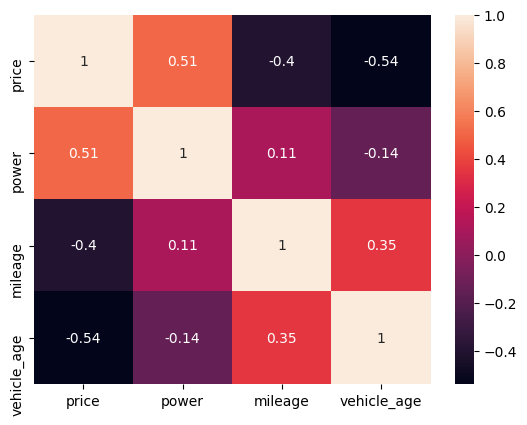

In [54]:
sns.heatmap(df.corr(), annot=True)

No hay alguna correlación especialmente alta, la más destacable seria con 'mileage', lo cual tiene sentido, es bien sabido que mientrás más millas (o kilómetros) recorridos tenga un auto,  
menor será el precio debido al desgaste. Revisaré ahora los boxplot 

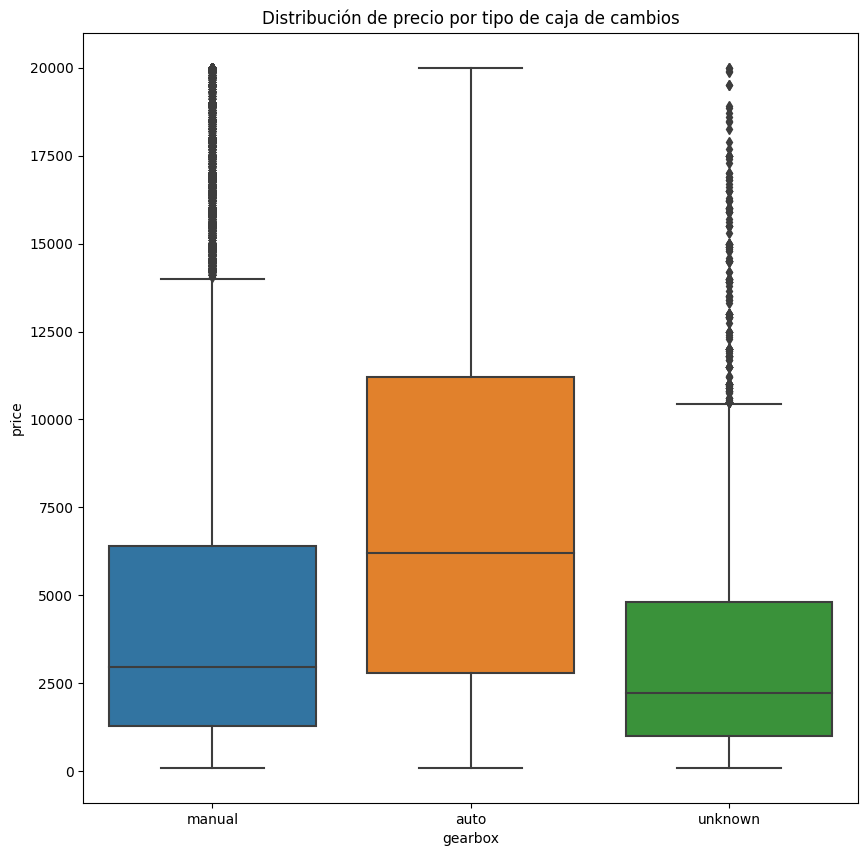

In [55]:
plt.figure(figsize=(10,10))
sns.boxplot(x = 'gearbox', y = 'price', data = df)
plt.title('Distribución de precio por tipo de caja de cambios')
plt.show()

Para 'manual' y 'unknown' hay muchos outliers por encima de los bigotes. De acuerdo a la gráfica, una caja automática tiene un precio de venta más alto.

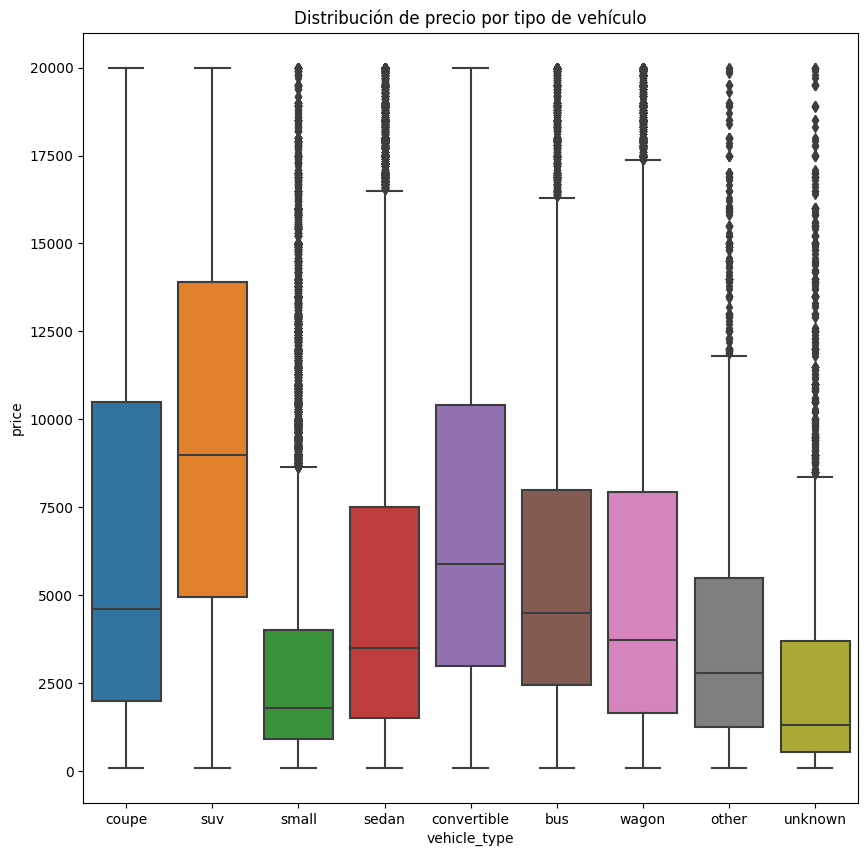

In [56]:
plt.figure(figsize=(10,10))
sns.boxplot(x = 'vehicle_type', y = 'price', data = df)
plt.title('Distribución de precio por tipo de vehículo')
plt.show()

Se puede ver que la media para 'suv' es superior al resto, sin emgargo para todos los otros tipos de vehículo (con la excepción de 'convertible') tienen muchos datos atípicos por encima de los bigotes.

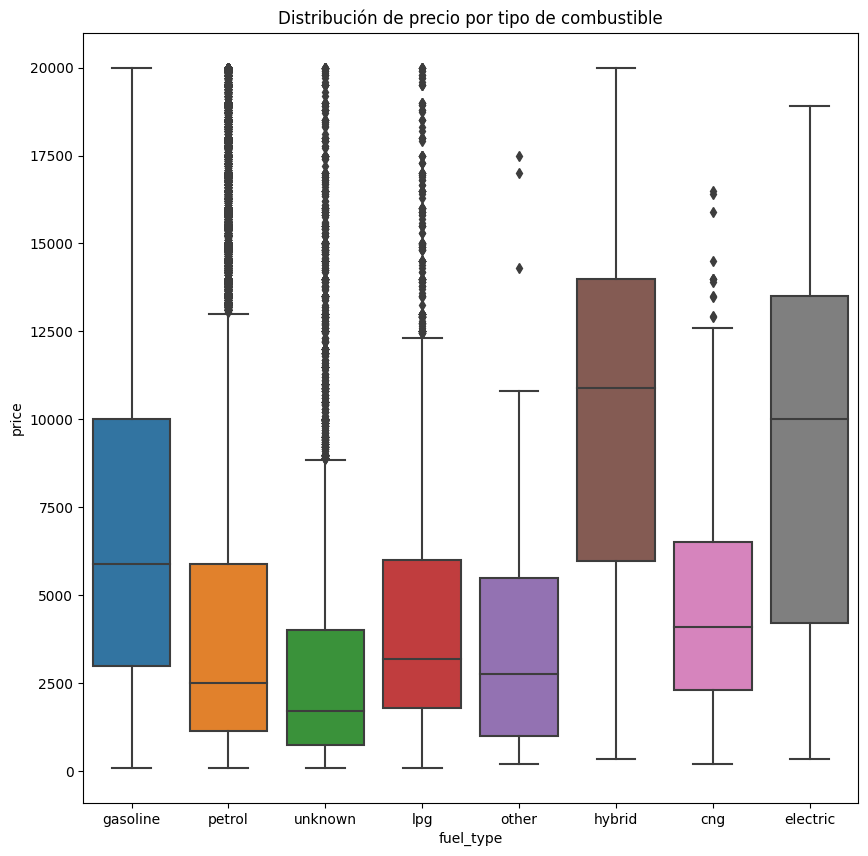

In [57]:
plt.figure(figsize=(10,10))
sns.boxplot(x = 'fuel_type', y = 'price', data = df)
plt.title('Distribución de precio por tipo de combustible')
plt.show()

Se puede apreciar una media superior para los híbridos, sin embargo la realidad es que los datos en general tienen mucha dispersión (bigotes muy largos o datos atípicos)

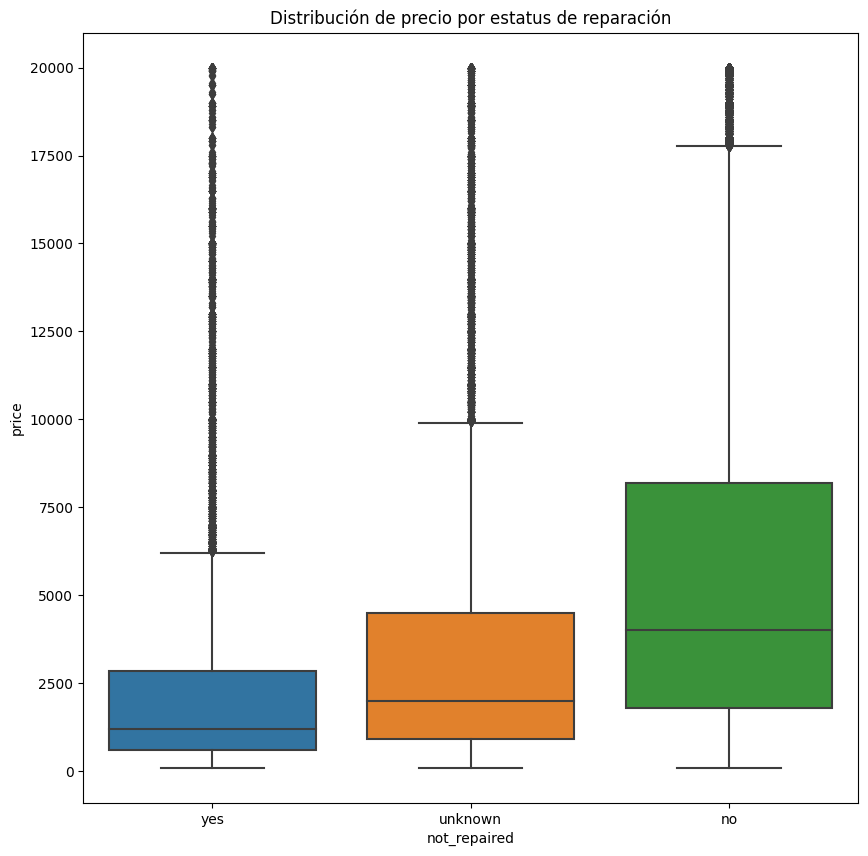

In [58]:
plt.figure(figsize=(10,10))
sns.boxplot(x = 'not_repaired', y = 'price', data = df)
plt.title('Distribución de precio por estatus de reparación')
plt.show()

De nuevo, datos muy dispersos, aparentemente el precio de un auto puede ser más alto si esté no ha sido reparado. En general no se puede ver una correlación fuerte con alguno de los datos, solo ciertas tendencias pero nada sólido.

### Creación de conjuntos 'train', 'test' y 'valid'

In [59]:
features = df.drop('price', axis=1)
target = df['price']

features_train, features_test, target_train, target_test = train_test_split(
    features, target, test_size=0.4, random_state=12345
)

features_test, features_valid, target_test, target_valid = train_test_split(
    features_test, target_test, test_size=0.5, random_state=12345
)
print(len(features_train))
print(len(features_test))
print(len(features_valid))

163573
54525
54525


### Cofificación de columnas categóricas

#### OHE

In [60]:
columnas_categoricas = ['vehicle_type', 'gearbox', 'model', 'fuel_type', 'brand', 'not_repaired']

features_train_ohe = pd.get_dummies(features_train, columns=columnas_categoricas, drop_first=True)
features_test_ohe = pd.get_dummies(features_test, columns=columnas_categoricas, drop_first=True)

# Alinea las columnas por si test tiene categorías que no aparecieron en train (o viceversa)
features_train_ohe, features_test_ohe = features_train_ohe.align(features_test_ohe, join='left', axis=1, fill_value=0)

#### Para LightGBM y CatBoost

In [61]:
features_train_cat = features_train.copy()
features_test_cat = features_test.copy()
features_valid_cat = features_valid.copy()

for col in columnas_categoricas:
    features_train_cat[col] = features_train_cat[col].astype('category')
    features_test_cat[col] = features_test_cat[col].astype('category')
    features_valid_cat[col] = features_valid_cat[col].astype('category')

## Entrenamiento del modelo 

### Bosque aleatorio

In [62]:
%%time
best_recm_bosque = 5000
best_estimator_bosque = 0
best_depth_bosque = 0
recm_bosque = []
tiempo_entrenamiento_bosque = []
tiempo_prediccion_bosque = []
for estimator in range(18, 28, 2):
    for depth in range(19, 24):
        print(f'Estimators: {estimator} | Depth: {depth}')
        modelo_bosque = RandomForestRegressor(n_estimators=estimator, max_depth=depth, random_state=12345)
        recm, tiempo_train, tiempo_pred = evaluar_modelo(modelo_bosque, features_train_ohe, target_train, features_test_ohe, target_test)
        if recm < best_recm_bosque:
            best_recm_bosque = recm
            best_estimator_bosque = estimator
            best_depth_bosque = depth
        recm_bosque.append(recm)
        tiempo_entrenamiento_bosque.append(tiempo_train)
        tiempo_prediccion_bosque.append(tiempo_pred)
print(f'El mejor resultado de RECM fue de: {best_recm_bosque} | Estimators: {best_estimator_bosque} | Depth: {best_depth_bosque}')

Estimators: 18 | Depth: 19
RECM: 1597.73
Tiempo de entrenamiento: 28.77s
Tiempo de predicción: 0.23s
Estimators: 18 | Depth: 20
RECM: 1590.43
Tiempo de entrenamiento: 29.75s
Tiempo de predicción: 0.25s
Estimators: 18 | Depth: 21
RECM: 1587.20
Tiempo de entrenamiento: 29.69s
Tiempo de predicción: 0.27s
Estimators: 18 | Depth: 22
RECM: 1582.13
Tiempo de entrenamiento: 30.88s
Tiempo de predicción: 0.29s
Estimators: 18 | Depth: 23
RECM: 1583.31
Tiempo de entrenamiento: 31.47s
Tiempo de predicción: 0.30s
Estimators: 20 | Depth: 19
RECM: 1595.38
Tiempo de entrenamiento: 31.97s
Tiempo de predicción: 0.26s
Estimators: 20 | Depth: 20
RECM: 1588.55
Tiempo de entrenamiento: 32.77s
Tiempo de predicción: 0.28s
Estimators: 20 | Depth: 21
RECM: 1584.82
Tiempo de entrenamiento: 34.42s
Tiempo de predicción: 0.30s
Estimators: 20 | Depth: 22
RECM: 1579.43
Tiempo de entrenamiento: 34.88s
Tiempo de predicción: 0.32s
Estimators: 20 | Depth: 23
RECM: 1581.07
Tiempo de entrenamiento: 35.77s
Tiempo de predicci

Dados los mejores parámetros encontrados, iteraré cerca de ellos para encontrar el óptimo

In [63]:
%%time
best_recm_bosque = 5000
best_estimator_bosque = 0
best_depth_bosque = 0
for estimator in range(26, 28):
    for depth in range(23, 26):
        print(f'Estimators: {estimator} | Depth: {depth}')
        modelo_bosque = RandomForestRegressor(n_estimators=estimator, max_depth=depth, random_state=12345)
        recm, tiempo_train, tiempo_pred = evaluar_modelo(modelo_bosque, features_train_ohe, target_train, features_test_ohe, target_test)
        if recm < best_recm_bosque:
            best_recm_bosque = recm
            best_estimator_bosque = estimator
            best_depth_bosque = depth
print(f'El mejor resultado de RECM fue de: {best_recm_bosque} | Estimators: {best_estimator_bosque} | Depth: {best_depth_bosque}')

Estimators: 26 | Depth: 23
RECM: 1573.79
Tiempo de entrenamiento: 45.65s
Tiempo de predicción: 0.44s
Estimators: 26 | Depth: 24
RECM: 1571.09
Tiempo de entrenamiento: 45.45s
Tiempo de predicción: 0.45s
Estimators: 26 | Depth: 25
RECM: 1569.82
Tiempo de entrenamiento: 45.57s
Tiempo de predicción: 0.46s
Estimators: 27 | Depth: 23
RECM: 1573.19
Tiempo de entrenamiento: 46.27s
Tiempo de predicción: 0.43s
Estimators: 27 | Depth: 24
RECM: 1570.65
Tiempo de entrenamiento: 46.79s
Tiempo de predicción: 0.47s
Estimators: 27 | Depth: 25
RECM: 1569.38
Tiempo de entrenamiento: 48.35s
Tiempo de predicción: 0.49s
El mejor resultado de RECM fue de: 1569.3797901772618 | Estimators: 27 | Depth: 25
CPU times: user 4min 39s, sys: 1.09 s, total: 4min 40s
Wall time: 4min 40s


### XGBoost

In [64]:
%%time
best_recm_xgb = 5000
best_estimators_xgb = 0
recm_xgb = []
tiempo_entrenamiento_xgb = []
tiempo_prediccion_xgb = []

for estimators in [100, 200]:
    print(f'Estimators: {estimators}')
    modelo_xgb = XGBRegressor(n_estimators=estimators, max_depth=7, learning_rate=0.15, random_state=12345)
    recm, tiempo_train, tiempo_pred = evaluar_modelo(modelo_xgb, features_train_ohe, target_train, features_test_ohe, target_test)
    if recm < best_recm_xgb:
        best_recm_xgb = recm
        best_estimators_xgb = estimators
    recm_xgb.append(recm)
    tiempo_entrenamiento_xgb.append(tiempo_train)
    tiempo_prediccion_xgb.append(tiempo_pred)
print(f'\nEl mejor resultado de RECM fue de: {best_recm_xgb} | Estimators: {best_estimators_xgb}')

Estimators: 100
RECM: 1619.41
Tiempo de entrenamiento: 157.28s
Tiempo de predicción: 0.32s
Estimators: 200
RECM: 1577.37
Tiempo de entrenamiento: 301.62s
Tiempo de predicción: 0.39s

El mejor resultado de RECM fue de: 1577.3676554454019 | Estimators: 200
CPU times: user 15min 16s, sys: 1.82 s, total: 15min 17s
Wall time: 7min 39s


### Regresión Lineal

In [65]:
%%time
modelo_regresion = LinearRegression()
recm_regresion, tiempo_train_regresion, tiempo_pred_regresion = evaluar_modelo(modelo_regresion, features_train_ohe, target_train, features_test_ohe, target_test)

RECM: 2539.94
Tiempo de entrenamiento: 5.50s
Tiempo de predicción: 0.17s
CPU times: user 6.93 s, sys: 3.78 s, total: 10.7 s
Wall time: 5.67 s


In [66]:
# Elimino el contenido de las variables 'ohe' para liberar espacio en disco
del features_train_ohe, features_test_ohe

### LightGBM

In [67]:
%%time
best_recm_lgbm = 5000
best_estimator_lgbm = 0
best_depth_lgbm = 0
best_learning_rate_lgbm = 0
recm_lgbm = []
tiempo_entrenamiento_lgbm = []
tiempo_prediccion_lgbm = []

for estimator in range(50, 301, 50):
    for depth in range(3, 12, 2):
        for learning in [0.01, 0.03, 0.05, 0.1, 0.15]:
            print(f'Estimators: {estimator} | Depth: {depth} | Learning rate: {learning}')
            modelo_lgbm = lgb.LGBMRegressor(n_estimators=estimator, max_depth=depth, learning_rate=learning, random_state=12345)
            recm, tiempo_train, tiempo_pred = evaluar_modelo(modelo_lgbm, features_train_cat, target_train, features_test_cat, target_test)
            if recm < best_recm_lgbm:
                best_recm_lgbm = recm
                best_estimator_lgbm = estimator
                best_depth_lgbm = depth
                best_learning_rate_lgbm = learning
            recm_lgbm.append(recm)
            tiempo_entrenamiento_lgbm.append(tiempo_train)
            tiempo_prediccion_lgbm.append(tiempo_pred)
print(f'El mejor resultado de RECM fue de: {best_recm_lgbm} | Estimators: {best_estimator_lgbm} | Depth: {best_depth_lgbm} | Learning rate: {best_learning_rate_lgbm}')

Estimators: 50 | Depth: 3 | Learning rate: 0.01
RECM: 3583.21
Tiempo de entrenamiento: 0.61s
Tiempo de predicción: 0.10s
Estimators: 50 | Depth: 3 | Learning rate: 0.03
RECM: 2573.74
Tiempo de entrenamiento: 0.50s
Tiempo de predicción: 0.11s
Estimators: 50 | Depth: 3 | Learning rate: 0.05
RECM: 2159.63
Tiempo de entrenamiento: 0.67s
Tiempo de predicción: 0.02s
Estimators: 50 | Depth: 3 | Learning rate: 0.1
RECM: 1859.98
Tiempo de entrenamiento: 0.59s
Tiempo de predicción: 0.09s
Estimators: 50 | Depth: 3 | Learning rate: 0.15
RECM: 1795.69
Tiempo de entrenamiento: 0.52s
Tiempo de predicción: 0.10s
Estimators: 50 | Depth: 5 | Learning rate: 0.01
RECM: 3362.80
Tiempo de entrenamiento: 0.88s
Tiempo de predicción: 0.10s
Estimators: 50 | Depth: 5 | Learning rate: 0.03
RECM: 2209.79
Tiempo de entrenamiento: 1.22s
Tiempo de predicción: 0.18s
Estimators: 50 | Depth: 5 | Learning rate: 0.05
RECM: 1857.84
Tiempo de entrenamiento: 0.89s
Tiempo de predicción: 0.11s
Estimators: 50 | Depth: 5 | Learn

### CatBoost

In [68]:
%%time
best_recm_cat = 5000
best_iterations_cat = 0
best_depth_cat = 0
best_learning_rate_cat = 0
recm_cat = []
tiempo_entrenamiento_cat = []
tiempo_prediccion_cat = []

for iterations in [100, 200, 300]:
    for depth in [5, 7, 9]:
        for learning in [0.05, 0.1, 0.15]:
            print(f'Iterations: {iterations} | Depth: {depth} | Learning rate: {learning}')
            modelo_catboost = CatBoostRegressor(iterations=iterations, depth=depth, learning_rate=learning, random_state=12345, verbose=0)
            recm, tiempo_train, tiempo_pred = evaluar_modelo(modelo_catboost, features_train_cat, target_train, features_test_cat, target_test, cat_features=columnas_categoricas)
            if recm < best_recm_cat:
                best_recm_cat = recm
                best_iterations_cat = iterations
                best_depth_cat = depth
                best_learning_rate_cat = learning
            recm_cat.append(recm)
            tiempo_entrenamiento_cat.append(tiempo_train)
            tiempo_prediccion_cat.append(tiempo_pred)

print(f'\nEl mejor resultado de RECM fue de: {best_recm_cat} | Iterations: {best_iterations_cat} | Depth: {best_depth_cat} | Learning rate: {best_learning_rate_cat}')

Iterations: 100 | Depth: 5 | Learning rate: 0.05
RECM: 1903.46
Tiempo de entrenamiento: 4.43s
Tiempo de predicción: 0.02s
Iterations: 100 | Depth: 5 | Learning rate: 0.1
RECM: 1785.34
Tiempo de entrenamiento: 4.34s
Tiempo de predicción: 0.02s
Iterations: 100 | Depth: 5 | Learning rate: 0.15
RECM: 1745.05
Tiempo de entrenamiento: 4.28s
Tiempo de predicción: 0.02s
Iterations: 100 | Depth: 7 | Learning rate: 0.05
RECM: 1822.59
Tiempo de entrenamiento: 5.71s
Tiempo de predicción: 0.02s
Iterations: 100 | Depth: 7 | Learning rate: 0.1
RECM: 1716.95
Tiempo de entrenamiento: 5.69s
Tiempo de predicción: 0.05s
Iterations: 100 | Depth: 7 | Learning rate: 0.15
RECM: 1680.71
Tiempo de entrenamiento: 5.70s
Tiempo de predicción: 0.02s
Iterations: 100 | Depth: 9 | Learning rate: 0.05
RECM: 1755.41
Tiempo de entrenamiento: 7.62s
Tiempo de predicción: 0.02s
Iterations: 100 | Depth: 9 | Learning rate: 0.1
RECM: 1675.44
Tiempo de entrenamiento: 7.58s
Tiempo de predicción: 0.04s
Iterations: 100 | Depth: 9 

### Hallazgos en los modelos

Se entrenaron y compararon cinco modelos para predecir el valor de mercado de los vehículos de Rusty Bargain: regresión lineal (prueba de cordura), bosque aleatorio, LightGBM, CatBoost y XGBoost (opcional), evaluados con RECM, tiempo de entrenamiento y tiempo de predicción.

Para los modelos con hiperparámetros ajustables, se realizó una búsqueda iterativa probando distintas combinaciones de número de árboles/iteraciones, profundidad y (para los modelos de potenciación del gradiente) tasa de aprendizaje, evaluando cada combinación mediante RECM sobre el conjunto de prueba. Se detuvo la búsqueda una vez que las mejoras de RECM entre combinaciones sucesivas se volvieron marginales (del orden de decimales) mientras que el tiempo de entrenamiento seguía creciendo de forma considerable. En el caso de XGBoost, el costo computacional fue tan alto (301.62s solo para entrenar con 200 estimadores) que se limitó la búsqueda a un rango reducido, ya que continuar hubiera implicado varios minutos adicionales sin garantía de una mejora significativa. Para el bosque aleatorio, tomé los datos de tiempo del primer approach ya que tiene más datos y estos serán mas representativos más adelante.

| Modelo | RECM | Tiempo de entrenamiento | Tiempo de predicción |
|---|---|---|---|
| Regresión lineal | 2539.94 | 5.50s | 0.17s |
| Bosque aleatorio | 1569.38 | 48.35s | 0.49s |
| **LightGBM** | **1532.41** | **3.29s** | 0.49s |
| CatBoost | 1557.54 | 61.63s | 0.17s |
| XGBoost | 1577.37 | 301.62s | 0.39s |

**Prueba de cordura:** la regresión lineal obtuvo el RECM más alto de los cinco modelos, confirmando que no hubo errores graves en la preparación de los datos ni en la configuración de los modelos de árboles, y evidenciando que la relación entre las características del vehículo (antigüedad, potencia, kilometraje, marca) y su precio no es lineal.

**Calidad de predicción:** los cuatro modelos basados en árboles obtuvieron resultados relativamente cercanos entre sí (RECM entre 1532 y 1577), con LightGBM a la cabeza, seguido de CatBoost, bosque aleatorio y XGBoost.

**Velocidad:** aquí se encontró la diferencia más determinante entre los modelos. LightGBM entrenó en 3.29 segundos, siendo drásticamente más rápido que sus competidores: ~15 veces más rápido que el bosque aleatorio, ~19 veces más rápido que CatBoost, y ~92 veces más rápido que XGBoost — este último, además de tener el mayor tiempo de entrenamiento, requirió codificación One-Hot (a diferencia de 
LightGBM y CatBoost, que manejan categóricas de forma nativa), lo que incrementó tanto la dimensionalidad de los datos como el costo computacional, sin traducirse en una mejora de calidad respecto a sus alternativas.

**Modelo recomendado:** considerando las tres prioridades de Rusty Bargain (calidad de la predicción, velocidad de predicción y tiempo de entrenamiento), **LightGBM** es la opción más adecuada: ofrece el mejor RECM de los cinco modelos evaluados con un costo computacional considerablemente menor que el resto — una ventaja especialmente relevante si el modelo necesita reentrenarse periódicamente conforme se actualice el inventario de la app. Vale la pena señalar que esta conclusión es específica al contexto de este proyecto (dataset grande, prioridad en velocidad de reentrenamiento); en escenarios con datasets más pequeños, presupuesto de ajuste de hiperparámetros limitado, o hardware con muchos núcleos disponibles para paralelización, un bosque aleatorio podría ser una alternativa más adecuada pese a no ofrecer el mejor RECM en este caso particular.

## Análisis del modelo

### Validación del modelo seleccionado con conjunto de validación

In [69]:
modelo_lgbm = lgb.LGBMRegressor(n_estimators=best_estimator_lgbm, max_depth=best_depth_lgbm, learning_rate=best_learning_rate_lgbm, random_state=12345)
recm, tiempo_train, tiempo_pred = evaluar_modelo(modelo_lgbm, features_train_cat, target_train, features_valid_cat, target_valid)

RECM: 1525.95
Tiempo de entrenamiento: 3.50s
Tiempo de predicción: 0.49s


### Validación del modelo vs los datos de entrenamiento
Compararé los resultados de RECM para validar que no exista un overfitting (si RECM para el conjunto 'train' es muy pequeño respecto a los otros, quiere decir que el modelo 'memorizó' los datos de entrenamiento)

In [70]:
recm, tiempo_train, tiempo_pred = evaluar_modelo(modelo_lgbm, features_train_cat, target_train, features_train_cat, target_train)

RECM: 1380.84
Tiempo de entrenamiento: 3.21s
Tiempo de predicción: 1.38s


### Validación del modelo seleccionado

Para confirmar que el modelo LightGBM seleccionado generaliza correctamente y no presenta sobreajuste, se comparó su desempeño (RECM) en los tres conjuntos disponibles:

| Conjunto | RECM |
|---|---|
| Train | 1380.84 |
| Test | 1532.41 |
| Valid | 1525.95 |

La diferencia entre train y test (11%) es moderada y esperable — indica que el modelo aprendió patrones generalizables en lugar de memorizar el conjunto de entrenamiento. Adicionalmente, la muy alta cercanía entre test y valid (0.4%), este último sin haber influido en ningún momento en la selección de hiperparámetros, confirma que el proceso de búsqueda no se sobreajustó al conjunto de prueba. En 
conjunto, estos resultados respaldan que el modelo LightGBM elegido es confiable para su uso en producción dentro de la app de Rusty Bargain.

### Validación gráfica de los tiempos de entrenamiento y predicción de los modelos
Durante el proceso de entrenamiento de los modelos almacené los datos de tiempo de entrenamiento y predicción, a continuación graficaré esos tiempos vs el resultado de RECM para comprobar cual es la opción que mejor optimiza tiempo y resultados.

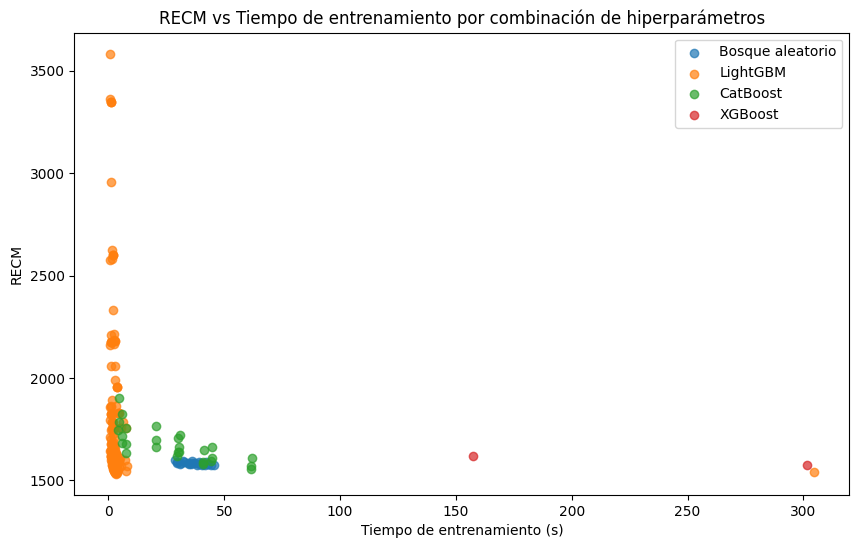

In [71]:
plt.figure(figsize=(10,6))
plt.scatter(tiempo_entrenamiento_bosque, recm_bosque, label='Bosque aleatorio', alpha=0.7)
plt.scatter(tiempo_entrenamiento_lgbm, recm_lgbm, label='LightGBM', alpha=0.7)
plt.scatter(tiempo_entrenamiento_cat, recm_cat, label='CatBoost', alpha=0.7)
plt.scatter(tiempo_entrenamiento_xgb, recm_xgb, label='XGBoost', alpha=0.7)

plt.xlabel('Tiempo de entrenamiento (s)')
plt.ylabel('RECM')
plt.title('RECM vs Tiempo de entrenamiento por combinación de hiperparámetros')
plt.legend()
plt.show()

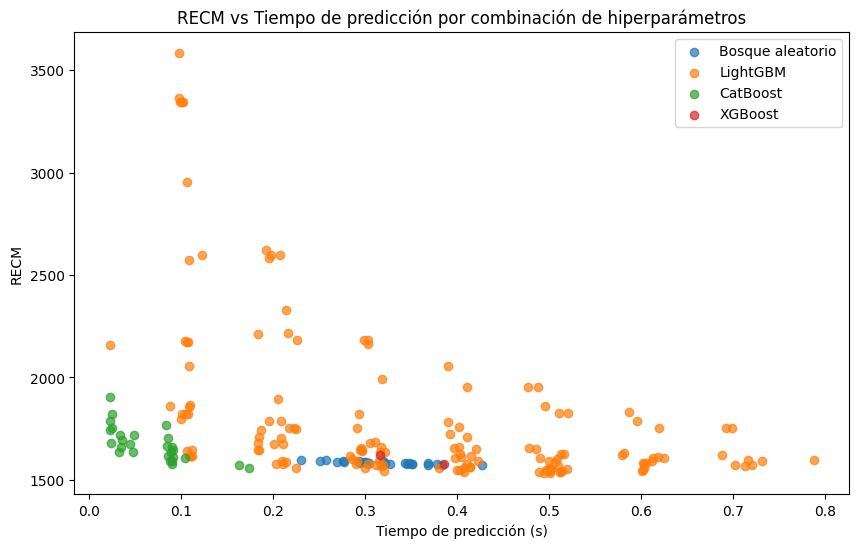

In [72]:
plt.figure(figsize=(10,6))
plt.scatter(tiempo_prediccion_bosque, recm_bosque, label='Bosque aleatorio', alpha=0.7)
plt.scatter(tiempo_prediccion_lgbm, recm_lgbm, label='LightGBM', alpha=0.7)
plt.scatter(tiempo_prediccion_cat, recm_cat, label='CatBoost', alpha=0.7)
plt.scatter(tiempo_prediccion_xgb, recm_xgb, label='XGBoost', alpha=0.7)

plt.xlabel('Tiempo de predicción (s)')
plt.ylabel('RECM')
plt.title('RECM vs Tiempo de predicción por combinación de hiperparámetros')
plt.legend()
plt.show()

Para los tiempos de entrenamiento, se puede observar que **LightGBM** tiene los menores tiempos y a la vez logra buenos resultados en RECM (estó ya lo validamos con los datos númericos anteriormente).  
Para los tiempos de predicción, se puede ver más concentrado en la parte inferior izquierda a **CatBoost**, lo que indica que en cuestión de tiempo de predicción este modelo es superior a los demás. Para **Bosque aleatorio** los datos tienen poca dispersión, pero el tiempo de predicción es mayor y el resultado de RECM es peor comparado con **CatBoost**.  
Considerando que el mayor esfuerzo en tiempo proviene del entrenamiento, y que el mejor resultado en RECM lo obtuvo **LightGBM** podemos confirmar que este fue el mejor modelo de los analizados.

## Conclusión general

Se desarrolló un modelo de machine learning para predecir el valor de mercado de vehículos usados para Rusty Bargain, cubriendo desde la limpieza de datos hasta la comparación y validación de múltiples algoritmos.

**Preparación de datos:** el dataset original (354,369 filas) presentaba múltiples problemas de calidad — 262 filas completamente duplicadas, valores imposibles en `registration_year` (años entre 1000 y 9999), `power` (0 CV) y `price` (precios de 0 a 1), así como una columna constante (`NumberOfPictures`) y ~20% de valores ausentes en `not_repaired`. Cada decisión de limpieza se respaldó con evidencia (análisis de percentiles, verificación de hipótesis alternativas contra otras columnas) en lugar de umbrales arbitrarios, resultando en un conjunto final de 272,623 filas (77% del original).

**Análisis exploratorio:** no se encontraron correlaciones numéricas extremadamente altas con `price`, siendo `mileage` la más relevante (relación inversa esperada). El análisis de `brand` vs `model` confirmó que, aunque el 97% de los modelos mapean a una única marca, existen casos genuinos de la industria (posibles alianzas comerciales o cambios de nombre de las marcas) que justificaron conservar ambas columnas.

**Comparación de modelos:** se entrenaron y compararon cinco modelos — regresión lineal (prueba de cordura), bosque aleatorio, LightGBM, CatBoost y XGBoost — mediante búsqueda iterativa de hiperparámetros, evaluando RECM, tiempo de entrenamiento y tiempo de predicción:

| Modelo | RECM | Tiempo de entrenamiento | Tiempo de predicción |
|---|---|---|---|
| Regresión lineal | 2539.94 | 5.50s | 0.17s |
| Bosque aleatorio | 1569.38 | 48.35s | 0.49s |
| **LightGBM** | **1532.41** | **3.29s** | 0.49s |
| CatBoost | 1557.54 | 61.63s | 0.17s |
| XGBoost | 1577.37 | 301.62s | 0.39s |

La regresión lineal, como prueba de cordura, obtuvo el peor RECM de los cinco, confirmando que la relación entre las características del vehículo y su precio no es lineal y que no hubo errores graves en la preparación de los datos. Las gráficas de RECM vs tiempo mostraron a LightGBM concentrado en la mejor zona posible (RECM bajo, tiempo de entrenamiento bajo), mientras que CatBoost destacó en tiempo de predicción. Bosque aleatorio, pese a tener poca dispersión en sus resultados, quedó por detrás en RECM frente a CatBoost, y XGBoost resultó el más lento de todos.

**Validación del modelo final:** LightGBM, seleccionado como mejor modelo, se validó comparando su RECM en los tres conjuntos disponibles (train: 1380.84, test: 1532.41, valid: 1525.95). La diferencia moderada entre train y test (11%) descartó memorización de los datos de entrenamiento, y la muy alta cercanía entre test y valid (0.4%) confirmó que la búsqueda de hiperparámetros no se sobreajustó al conjunto de prueba.

**Recomendación final:** se recomienda **LightGBM** como modelo de producción para la app de Rusty Bargain. No solo ofrece el mejor RECM de los cinco modelos evaluados, sino que lo logra con un tiempo de entrenamiento drásticamente menor que sus competidores más cercanos en calidad (hasta ~92 veces más rápido que XGBoost) — una ventaja clave considerando que el modelo probablemente necesitará reentrenarse con regularidad conforme se actualice el inventario de vehículos. Se identificó además que esta recomendación es específica al contexto de este proyecto (dataset grande, prioridad en velocidad de reentrenamiento); en escenarios con datasets más pequeños o mayor disponibilidad de cómputo paralelo, un bosque aleatorio podría ser una alternativa competitiva pese a no ganar en este caso particular.

# Lista de control

Escribe 'x' para verificar. Luego presiona Shift+Enter

- [x]  Jupyter Notebook está abierto
- [x]  El código no tiene errores
- [x]  Las celdas con el código han sido colocadas en orden de ejecución
- [x]  Los datos han sido descargados y preparados
- [x]  Los modelos han sido entrenados
- [x]  Se realizó el análisis de velocidad y calidad de los modelos